#Theoretical

1.What is a Support Vector Machine (SVM)?

->A **Support Vector Machine (SVM)** is a **supervised machine learning algorithm** used primarily for **classification** tasks but can also be used for **regression** and **outlier detection**.

### ✅ **Core Idea of SVM:**

SVM tries to find the **best decision boundary (hyperplane)** that separates data points of different classes **with the maximum possible margin** between them.

---

### 🔎 **Key Concepts:**

| Concept                  | Description                                                                                                                                                                                             |
| ------------------------ | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Hyperplane**           | A line (in 2D), a plane (in 3D), or a higher-dimensional surface that separates data into classes.                                                                                                      |
| **Margin**               | The distance between the hyperplane and the nearest data points from each class (called **support vectors**). SVM tries to maximize this margin.                                                        |
| **Support Vectors**      | The data points that are closest to the hyperplane. These directly affect the position of the hyperplane.                                                                                               |
| **Linear vs Non-linear** | If data is **linearly separable**, SVM finds a straight hyperplane. If not, it uses a technique called the **kernel trick** to project data into higher dimensions to make it separable.                |
| **Kernel Trick**         | A mathematical technique that allows SVM to solve non-linear problems using functions like **RBF (Radial Basis Function)**, **Polynomial**, etc., without explicitly mapping data into high dimensions. |

---

### 📦 **Types of SVM:**

1. **Linear SVM** – when data is linearly separable.
2. **Non-linear SVM** – uses kernel functions to handle complex, non-linear boundaries.

---

### 🏁 **Advantages of SVM:**

* Effective in **high-dimensional spaces**.
* Works well when the number of dimensions > number of samples.
* Memory efficient — uses only **support vectors**.

### ⚠️ **Limitations:**

* Can be slow with large datasets.
* Selecting the right **kernel** and tuning parameters (**C**, **gamma**) can be tricky.
* Doesn't perform well with overlapping classes or noisy datasets.

---

### ✅ **Common Kernels in SVM:**

| Kernel             | Use Case                             |
| ------------------ | ------------------------------------ |
| **Linear**         | When data is linearly separable      |
| **Polynomial**     | For polynomial relationships         |
| **RBF (Gaussian)** | Common for most non-linear datasets  |
| **Sigmoid**        | Similar to neural network activation |

---

### 📌 **SVM in Python (Example with scikit-learn):**

```python
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create SVM model
model = SVC(kernel='rbf', C=1, gamma='scale')

# Train and predict
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
```

---



2.What is the difference between Hard Margin and Soft Margin SVM?

->Great question! The difference between **Hard Margin** and **Soft Margin** SVM comes down to how strictly the algorithm tries to separate classes, especially when the data is noisy or not perfectly linearly separable.

---

### 🔹 **Hard Margin SVM:**

* Assumes that the data is **completely linearly separable** with no errors.
* Finds a hyperplane that **perfectly separates** the classes with the **maximum margin**.
* **No misclassification** or data points inside the margin are allowed.
* Works well when the dataset is **clean** and **noise-free**.
* **Limitation:** It is **not robust** to noise or overlapping classes. If the data is not linearly separable, Hard Margin SVM **fails** or cannot find a solution.

---

### 🔹 **Soft Margin SVM:**

* Allows **some misclassifications** or violations (i.e., some data points can be inside the margin or misclassified).
* Introduces **slack variables** to permit violations of the margin constraints.
* Balances between maximizing the margin and minimizing classification errors.
* Controlled by a **regularization parameter C**:

  * **Large C:** Less tolerance for misclassification (behaves more like Hard Margin).
  * **Small C:** More tolerance, allows more misclassifications but tries to maximize margin.
* More **flexible** and works well for **noisy** or **non-linearly separable** data.

---

### ⚡ **Summary Table:**

| Feature            | Hard Margin SVM                            | Soft Margin SVM                                                       |
| ------------------ | ------------------------------------------ | --------------------------------------------------------------------- |
| Data separability  | Requires perfect linear separability       | Allows non-separable or noisy data                                    |
| Margin violation   | Not allowed                                | Allowed, controlled by slack variables                                |
| Misclassification  | Zero misclassification                     | Some misclassification allowed                                        |
| Regularization (C) | No regularization parameter                | Regularization parameter **C** controls penalty for misclassification |
| Use case           | Clean, noise-free, linearly separable data | Real-world noisy data, overlapping classes                            |

---

### Intuition:

* **Hard Margin = Strict “No mistakes allowed.”**
* **Soft Margin = “Okay, we can allow some mistakes to get a better overall model.”**

---



3. What is the mathematical intuition behind SVM?

->Excellent! Let's dive into the **mathematical intuition** behind Support Vector Machines (SVM) in a clear, structured way.

---

## ✅ **Goal of SVM (Classification):**

To **find the optimal hyperplane** that separates two classes **with the largest possible margin**.

---

### 📌 **Mathematical Setup (For Linearly Separable Data):**

1. **Hyperplane Equation (in n dimensions):**

   $$
   w \cdot x + b = 0
   $$

   * $w$ → Weight vector (perpendicular to hyperplane)
   * $x$ → Input feature vector
   * $b$ → Bias (offset)

2. **Classification Condition:**

   * For **Class 1 (label = +1)** → $w \cdot x + b \ge +1$
   * For **Class 2 (label = -1)** → $w \cdot x + b \le -1$

So the constraint for all data points $(x_i, y_i)$ is:

$$
y_i (w \cdot x_i + b) \ge 1
$$

---

### 🟢 **Margin:**

* **Margin = Distance between the closest data points of each class and the hyperplane.**
* Formula for margin:

$$
\text{Margin} = \frac{2}{||w||}
$$

→ **SVM wants to maximize this margin.**

---

### 🎯 **Optimization Objective:**

**Maximize margin** ⇔ **Minimize** $||w||^2$

So the optimization problem becomes:

$$
\min_{w, b} \frac{1}{2} ||w||^2
$$

subject to:

$$
y_i (w \cdot x_i + b) \ge 1, \quad \forall i
$$

---

### 📌 **Soft Margin (Real-World, Noisy Data):**

For data that isn’t perfectly separable, **slack variables ($\xi_i$)** are introduced to allow some violations:

$$
y_i (w \cdot x_i + b) \ge 1 - \xi_i, \quad \xi_i \ge 0
$$

Now the optimization becomes:

$$
\min_{w, b, \xi} \frac{1}{2} ||w||^2 + C \sum \xi_i
$$

* $C$ → **Regularization parameter**: trade-off between **margin size** and **misclassification penalty**.

---

### 🔗 **Dual Form & Kernel Trick (For Non-linear SVMs):**

* The optimization problem can be rewritten in its **dual form** using Lagrange multipliers:

$$
\max_\alpha \sum \alpha_i - \frac{1}{2} \sum \sum \alpha_i \alpha_j y_i y_j (x_i \cdot x_j)
$$

subject to:

$$
\sum \alpha_i y_i = 0, \quad 0 \le \alpha_i \le C
$$

* **Kernel Trick** replaces the dot product $(x_i \cdot x_j)$ with a kernel function $K(x_i, x_j)$ to handle non-linearity.

---

### ✅ **Decision Function (Prediction):**

$$
f(x) = \text{sign} \left(\sum \alpha_i y_i K(x_i, x) + b\right)
$$

* The **support vectors** are the data points where $\alpha_i > 0$.

---

### ⚡ **Intuitive Summary:**

1. **SVM tries to find the widest street (margin)** that can separate two cities (classes) with houses (data points) on either side.
2. **Support vectors** are the houses closest to the road—they decide exactly where the road should go.
3. If the cities overlap (non-linearly), SVM uses **mathematical tricks (kernels)** to project the map into 3D (or higher dimensions), making it easier to draw a straight road.

---



4.What is the role of Lagrange Multipliers in SVM

->Great question!

### **Role of Lagrange Multipliers in Support Vector Machines (SVM):**

Lagrange multipliers play a **critical role** in the optimization problem of SVMs, especially when deriving the **dual form** of the SVM. They help in transforming a **constrained optimization problem** into a form that is easier to solve, particularly when using kernels.

Let’s break it down clearly:

---

## **1️⃣ The Optimization Problem in SVM (Primal Form)**

For a **hard-margin** SVM (linearly separable case), the objective is to:

**Minimize:**

$$
\frac{1}{2} \|w\|^2
$$

**Subject to (constraints):**

$$
y_i(w \cdot x_i + b) \geq 1 \quad \text{for all } i
$$

Where:

* $w$ = weight vector
* $b$ = bias
* $y_i$ = class label ($+1$ or $-1$)
* $x_i$ = feature vectors

---

## **2️⃣ Why Lagrange Multipliers?**

To **incorporate these constraints** into the optimization problem, we use **Lagrange multipliers** $\alpha_i \ge 0$, one for each constraint.

### **Lagrangian Function:**

$$
L(w, b, \alpha) = \frac{1}{2} \|w\|^2 - \sum_{i=1}^{n} \alpha_i [y_i(w \cdot x_i + b) - 1]
$$

* Here, the $\alpha_i$’s measure **how important** each constraint is in achieving the optimal margin.

---

## **3️⃣ Deriving the Dual Form (with Lagrange Multipliers):**

By optimizing $L$ with respect to $w$ and $b$, and then plugging these back into $L$, we derive the **dual problem**:

$$
\text{Maximize:} \quad W(\alpha) = \sum_{i=1}^n \alpha_i - \frac{1}{2} \sum_{i=1}^n \sum_{j=1}^n \alpha_i \alpha_j y_i y_j (x_i \cdot x_j)
$$

$$
\text{Subject to:} \quad \sum_{i=1}^n \alpha_i y_i = 0, \quad \alpha_i \ge 0
$$

---

## ✅ **Importance of Lagrange Multipliers in SVM:**

| Aspect                       | Role of Lagrange Multipliers                                                               |
| ---------------------------- | ------------------------------------------------------------------------------------------ |
| **Incorporate constraints**  | Ensure that all training points are on the correct side.                                   |
| **Identify support vectors** | $\alpha_i > 0$ **⇨** corresponding $x_i$ is a **support vector**.                          |
| **Simplify optimization**    | Transform the constrained problem to an easier dual problem.                               |
| **Enable kernel trick**      | Dual form depends only on dot products **$(x_i \cdot x_j)$**, enabling use of **kernels**. |

---

## **4️⃣ Summary**

* Lagrange multipliers **help solve SVM optimization** by encoding the constraints into the objective function.
* They **identify support vectors** through the non-zero multipliers.
* **Dual formulation** derived using Lagrange multipliers is essential for applying **kernel methods** to solve **non-linear SVMs**.



5.What are Support Vectors in SVM?

->Excellent question again — **Support Vectors** are at the *heart* of how SVM works.

### ✅ **Definition of Support Vectors in SVM:**

> **Support Vectors** are the **data points** that lie **closest to the decision boundary (hyperplane)** in an SVM model.
> These points are **"critical"** in defining the position and orientation of the hyperplane that separates the two classes.

---

### 📌 **Why Are They Important?**

* They are the **"support"** of the optimal hyperplane.
* If you remove a **support vector**, the decision boundary **will change**.
* Non-support vector points **don’t affect** the position of the hyperplane.
* **The margin** (the distance between the hyperplane and the closest points from each class) is **determined by these points.**

---

### ✅ **Mathematically:**

From the SVM optimization:

$$
y_i (w \cdot x_i + b) = 1
$$

* This equation holds **exactly** for **support vectors**.
* For other points:

$$
y_i (w \cdot x_i + b) > 1
$$

* In the **dual form** (using Lagrange multipliers $\alpha_i$):

  * **If $\alpha_i > 0$** → $x_i$ is a **support vector**.
  * **If $\alpha_i = 0$** → $x_i$ is **not** a support vector.

---

### ✅ **Visualization Example:**

For a **2D classification** problem:

```
Class +1     |     Class -1
     ●       |        ○
     ●       |        ○
     ●●● ●●  |  ○○ ○○ ○
         ↑   |      ↑
      Support Vectors
```

* **The hyperplane is defined by these circled points (●, ○).**
* **Only the support vectors affect the optimal hyperplane.**

---

### ✅ **Types of Points in SVM:**

| Type of Point           | Property                                                |
| ----------------------- | ------------------------------------------------------- |
| **Support Vectors**     | Lie on the margin, critical for defining the hyperplane |
| **Non-Support Vectors** | Lie outside the margin, do not affect the hyperplane    |

---

### ✅ **Why Are They Useful?**

1. **Sparsity:**
   The model depends **only on the support vectors**, making SVM memory-efficient for sparse problems.

2. **Robustness:**
   Adding or removing non-support vectors **won’t change** the decision boundary → good generalization.

3. **Kernel Trick:**
   In non-linear SVMs with kernels, only **support vectors** contribute to predictions.

---

### 📌 **Summary Table**

| **Aspect**       | **Support Vectors**                                 |
| ---------------- | --------------------------------------------------- |
| **Definition**   | Points lying closest to the decision boundary       |
| **Mathematical** | Have $\alpha_i > 0$ in dual form                    |
| **Purpose**      | Define the margin and hyperplane of the SVM         |
| **Impact**       | Removal **changes** the decision boundary           |
| **Sparsity**     | Only **support vectors** used in making predictions |

---



6.What is a Support Vector Classifier (SVC)?

->Great — let's make this **crystal clear**.

---

## ✅ **What is a Support Vector Classifier (SVC)?**

> **Support Vector Classifier (SVC)** is the **implementation of Support Vector Machine (SVM)** specifically designed for **classification** tasks.

In simple terms:

* **SVM** is the *general* algorithm — can be used for both **classification** and **regression**.
* **SVC** refers specifically to **Support Vector Classification**, commonly provided in libraries like **scikit-learn** (`sklearn.svm.SVC`).

---

## 📌 **Core Idea of SVC**

* Find a **decision boundary (hyperplane)** that best separates classes in the dataset.
* Tries to **maximize the margin** between the two classes.
* Can handle:

  1. **Linearly separable** data (hard-margin SVC)
  2. **Non-linearly separable** data using **kernels** (soft-margin SVC with kernel trick)

---

### ✅ **Mathematical Objective (Soft-Margin):**

**Minimize:**

$$
\frac{1}{2} \|w\|^2 + C \sum_{i=1}^{n} \xi_i
$$

**Subject to:**

$$
y_i(w \cdot x_i + b) \geq 1 - \xi_i, \quad \xi_i \ge 0
$$

Where:

* $w$ = weight vector
* $C$ = regularization parameter (controls trade-off between maximizing margin and minimizing classification error)
* $\xi_i$ = slack variables (allow for misclassification)
* $y_i \in \{-1, 1\}$

---

### ✅ **Features of SVC:**

| **Feature**           | **Details**                                               |
| --------------------- | --------------------------------------------------------- |
| **Type**              | Binary or multi-class classification                      |
| **Linear/Nonlinear**  | Can handle both with **kernel trick**                     |
| **Kernels Available** | `linear`, `poly`, `rbf` (Gaussian), `sigmoid`, or custom  |
| **Regularization**    | `C` parameter controls balance between margin and error   |
| **Support Vectors**   | Relies on *support vectors* to define decision boundaries |

---

### ✅ **SVC vs LinearSVC (Common Confusion):**

| **SVC (`sklearn.svm.SVC`)**   | **LinearSVC (`sklearn.svm.LinearSVC`)** |
| ----------------------------- | --------------------------------------- |
| Uses **kernel trick**         | **Linear kernel only**                  |
| Solves **dual form**          | Solves **primal form**                  |
| Better for **small datasets** | Scales better for **large datasets**    |

---

### ✅ **Example (Python Code):**

```python
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Generate toy data
X, y = make_classification(n_samples=100, n_features=2, n_classes=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Create and train SVC model
model = SVC(kernel='rbf', C=1.0)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
```

---

## 📌 **Summary Table:**

| **Aspect**           | **Support Vector Classifier (SVC)**              |
| -------------------- | ------------------------------------------------ |
| **Purpose**          | Classification (binary/multi-class)              |
| **Algorithm**        | Uses SVM algorithm for classification            |
| **Supports Kernels** | ✅ (`linear`, `rbf`, `poly`, etc.)                |
| **Key Parameter**    | `C` (regularization), `kernel`, `gamma`          |
| **Output**           | Decision boundary defined by **support vectors** |

---



7.What is a Support Vector Regressor (SVR)?

->Great — now you’re asking about the **regression** counterpart of SVM, called **SVR**. Let’s make this clear and structured.

---

## ✅ **What is a Support Vector Regressor (SVR)?**

> **Support Vector Regressor (SVR)** is the **regression version** of Support Vector Machines (SVM).
> Instead of predicting **classes**, SVR predicts **continuous numerical values**.

---

## 📌 **Goal of SVR:**

The **main goal of SVR** is to find a function $f(x)$ that **approximates the relationship between features and a continuous target variable**, with an **acceptable error margin** (epsilon-insensitive zone).

* It tries to fit the data within a **tube** of width $2\epsilon$ around the predicted values.
* Points **inside** the tube → **No penalty**
* Points **outside** the tube → **Penalty added** to the loss function.

---

## ✅ **Mathematical Formulation:**

**Minimize:**

$$
\frac{1}{2} \|w\|^2 + C \sum_{i=1}^n (\xi_i + \xi_i^*)
$$

**Subject to:**

$$
y_i - w \cdot x_i - b \leq \epsilon + \xi_i
$$

$$
w \cdot x_i + b - y_i \leq \epsilon + \xi_i^*
$$

$$
\xi_i, \xi_i^* \geq 0
$$

Where:

* $w$ → weight vector
* $b$ → bias
* $\epsilon$ → **margin of tolerance** (tube width)
* $\xi_i, \xi_i^*$ → slack variables for exceeding the tube
* $C$ → regularization parameter (controls trade-off between flatness and tolerance for errors)

---

## ✅ **How SVR Works:**

| **Aspect**          | **Explanation**                                                       |
| ------------------- | --------------------------------------------------------------------- |
| **Flatness**        | SVR tries to keep the model as **flat** as possible (small $w$).      |
| **Epsilon-tube**    | Predictions within $\pm \epsilon$ of actual value are **acceptable**. |
| **Errors**          | Only **points outside** the epsilon-tube incur a **penalty**.         |
| **Support Vectors** | Data points **outside** the epsilon-tube become **support vectors**.  |

---

## ✅ **Parameters of SVR (scikit-learn):**

| **Parameter** | **Meaning**                                      |
| ------------- | ------------------------------------------------ |
| `C`           | Penalty for points outside the epsilon-tube      |
| `epsilon`     | Width of the epsilon-tube                        |
| `kernel`      | Type of kernel (`linear`, `rbf`, `poly`, etc.)   |
| `gamma`       | Kernel coefficient (used in `rbf`, `poly`, etc.) |

---

## ✅ **Example (Python Code):**

```python
from sklearn.svm import SVR
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Generate synthetic regression data
X, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Create and train SVR model
svr = SVR(kernel='rbf', C=100, epsilon=10)
svr.fit(X_train, y_train)

# Plot results
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, svr.predict(X), color='red', label='SVR Prediction')
plt.legend()
plt.show()
```

---

## ✅ **Summary Table:**

| **Aspect**         | **Support Vector Regressor (SVR)**                |
| ------------------ | ------------------------------------------------- |
| **Purpose**        | Regression (predicting continuous values)         |
| **Key Concept**    | Fits a flat function within a margin of tolerance |
| **Penalty**        | Only for predictions **outside** $\epsilon$-tube  |
| **Kernels**        | ✅ (linear, polynomial, RBF, sigmoid, etc.)        |
| **Key Parameters** | `C`, `epsilon`, `kernel`, `gamma`                 |

---



8.What is the Kernel Trick in SVM?

->Excellent — the **Kernel Trick** is one of the most **powerful concepts** in Support Vector Machines (SVM). Let’s break it down **clearly and practically**:

---

## ✅ **What is the Kernel Trick in SVM?**

> **The Kernel Trick allows SVM to solve problems that are *not* linearly separable by implicitly mapping the data into a **higher-dimensional space** — *without explicitly computing that mapping*.**

In other words:

* Some datasets **cannot** be separated by a straight line (or hyperplane) in their original space.
* By **transforming** the data into a higher-dimensional space, they **can** become linearly separable.
* The **kernel trick** computes **dot products** in this **higher-dimensional space** **without actually performing the transformation**, saving computational resources.

---

### 📌 **Why is this Useful?**

* **Linear SVM → works on simple, linearly separable data.**
* **Non-linear SVM → uses the Kernel Trick to classify complex, non-linearly separable data.**

---

## ✅ **How Does It Work?**

Instead of computing:

$$
\phi(x_i) \cdot \phi(x_j)
$$

(where $\phi(x)$ is a complex or infinite transformation),

You compute a **kernel function** directly on the original data:

$$
K(x_i, x_j) = \phi(x_i) \cdot \phi(x_j)
$$

→ **Computational shortcut**.

---

## ✅ **Common Kernels Used in SVM:**

| **Kernel**         | **Mathematical Form**                     | **Usage**                               |
| ------------------ | ----------------------------------------- | --------------------------------------- |
| **Linear**         | $K(x, x') = x \cdot x'$                   | When data is already linearly separable |
| **Polynomial**     | $K(x, x') = (x \cdot x' + c)^d$           | For polynomial relationships            |
| **RBF (Gaussian)** | $K(x, x') = \exp(-\gamma \|x - x'\|^2)$   | For most general non-linear problems    |
| **Sigmoid**        | $K(x, x') = \tanh(\alpha x \cdot x' + c)$ | Rare, inspired by neural networks       |

---

## ✅ **Example Intuition (2D to 3D):**

Imagine trying to separate concentric circles:

**In 2D → Not Linearly Separable:**

```
o o o o
  ● ● ● ●
o o o o
```

**In 3D (after transformation) → Linearly Separable by a Plane.**

The **RBF kernel** helps to *implicitly* map that data into higher dimensions where SVM can find a **linear separator** (hyperplane).

---

## ✅ **Python Example:**

```python
from sklearn.svm import SVC
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt

# Generate concentric circle data
X, y = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)

# Train SVC with RBF kernel
model = SVC(kernel='rbf', C=1.0, gamma='scale')
model.fit(X, y)

# Plotting
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')
plt.title("Non-linear Classification with Kernel Trick (RBF Kernel)")
plt.show()
```

---

## ✅ **Advantages of the Kernel Trick:**

| **Advantage**             | **Explanation**                                                |
| ------------------------- | -------------------------------------------------------------- |
| **Non-linear separation** | Can classify data not separable by straight lines.             |
| **Efficiency**            | Avoids explicitly calculating high-dimensional feature spaces. |
| **Flexibility**           | Different kernels for different types of data relationships.   |

---

## ✅ **Summary Table:**

| **Concept**        | **Kernel Trick**                                                       |
| ------------------ | ---------------------------------------------------------------------- |
| **Purpose**        | Enables SVM to perform **non-linear classification**                   |
| **How it works**   | Computes **dot products in high dimensions** via a **kernel function** |
| **Common Kernels** | Linear, Polynomial, **RBF (most common)**, Sigmoid                     |
| **Efficiency**     | Saves computation by **avoiding explicit transformation**              |

---


9.Compare Linear Kernel, Polynomial Kernel, and RBF Kernel

->Great — comparing **Linear**, **Polynomial**, and **RBF** kernels is essential for understanding **which kernel to use** in SVM. Here's a **clear, structured comparison** for you:

---

## ✅ **Comparison of Linear Kernel, Polynomial Kernel, and RBF Kernel**

| **Aspect**             | **Linear Kernel**                      | **Polynomial Kernel**                              | **RBF Kernel (Gaussian)**                     |
| ---------------------- | -------------------------------------- | -------------------------------------------------- | --------------------------------------------- |
| **Formula**            | $K(x, x') = x \cdot x'$                | $K(x, x') = (x \cdot x' + c)^d$                    | $K(x, x') = \exp(-\gamma \|x - x'\|^2)$       |
| **Parameters**         | None (or just regularization **C**)    | Degree $d$, coefficient $c$                        | $\gamma$ (width of Gaussian), **C**           |
| **Non-linearity**      | ❌ Linear only                          | ✅ Non-linear                                       | ✅ Highly non-linear                           |
| **Best for**           | Linearly separable data                | Data with polynomial relationships                 | Complex, highly non-linear relationships      |
| **Computational Cost** | ✅ Low                                  | ❗ Medium to High (increases with **degree d**)     | ❗ High (but flexible, works on many problems) |
| **Flexibility**        | ❗ Low                                  | ✅ Medium                                           | ✅✅ Very high                                  |
| **Overfitting Risk**   | ❗ Low (good generalization)            | ⚠️ Medium-High if **degree d** is large            | ⚠️ High if **γ** is too large                 |
| **Example Use**        | Text classification, high-dim features | Data with interactions or curvature (e.g., images) | Most general-purpose kernel                   |

---

## ✅ **1️⃣ Linear Kernel**

* **Use When:** Data is **linearly separable** or **high-dimensional** (e.g., text, word counts, TF-IDF vectors).
* **Pros:**

  * Simple, fast
  * Low risk of overfitting
* **Cons:**

  * Can’t handle **non-linear** relationships.
* **Example:**
  Spam detection, sentiment analysis with bag-of-words.

---

## ✅ **2️⃣ Polynomial Kernel**

* **Use When:** Relationship between features and target involves **curves** or **polynomial terms**.
* **Pros:**

  * Captures **curved** relationships
  * Parameterizable: **degree d** controls flexibility
* **Cons:**

  * **Slow** for large datasets or high degrees
  * **Risk of overfitting** if degree is too high
* **Example:**
  Image data where patterns have **geometric or polynomial relations**.

---

## ✅ **3️⃣ RBF Kernel (Gaussian Kernel)**

* **Use When:** Relationship between features and target is **complex or unknown**.
* **Pros:**

  * Very **flexible**, **non-linear**
  * Works well in most general cases
* **Cons:**

  * More prone to **overfitting** (requires careful tuning of **γ** and **C**)
  * Computationally expensive for **large datasets**
* **Example:**
  Handwriting recognition, non-linear datasets like concentric circles.

---

## ✅ **Summary Table**

| **Kernel**     | **Use Case**                   | **Flexibility** | **Risk of Overfitting** | **Computation** |
| -------------- | ------------------------------ | --------------- | ----------------------- | --------------- |
| **Linear**     | Linear relationships, high-dim | ❗ Low           | ✅ Low                   | ✅ Fast          |
| **Polynomial** | Polynomial/circular relations  | ✅ Medium        | ⚠️ Medium-High          | ❗ Medium-High   |
| **RBF**        | Unknown, complex patterns      | ✅✅ Very High    | ⚠️ High                 | ❗❗ Slower       |

---

### ✅ **Quick Decision Guide:**

| **If...**                        | **Use**               |
| -------------------------------- | --------------------- |
| Data is **linear or high-dim**   | **Linear Kernel**     |
| Data has **polynomial patterns** | **Polynomial Kernel** |
| Data is **complex/non-linear**   | **RBF Kernel**        |

---



10.What is the effect of the C parameter in SVM?

->Excellent question — the **C parameter** is **crucial** for controlling the **behavior** of SVM.

Let’s break it down **clearly**:

---

## ✅ **What is the C Parameter in SVM?**

> **C is the regularization parameter in SVM.**
> It **controls the trade-off between having a wide margin (simplicity) and correctly classifying training points (accuracy on training data).**

---

## ✅ **How Does C Affect SVM?**

| **If C is large (e.g., 1000)**                    | **If C is small (e.g., 0.01)**                                          |
| ------------------------------------------------- | ----------------------------------------------------------------------- |
| **Focuses on minimizing errors on training data** | **Focuses on maximizing the margin (simplicity of the model)**          |
| **Narrow margin → complex decision boundary**     | **Wide margin → simpler, smoother boundary**                            |
| **Low bias, high variance (risk of overfitting)** | **High bias, low variance (risk of underfitting)**                      |
| **Allows fewer misclassifications**               | **Allows more misclassifications (but possibly better generalization)** |

---

## ✅ **Intuition:**

| **C Value** | **Model Behavior**                                                                                                 |
| ----------- | ------------------------------------------------------------------------------------------------------------------ |
| **High C**  | "Classify *everything* correctly, even if margin is small." ⚠️ Risk of **overfitting**                             |
| **Low C**   | "I’m okay with some misclassifications if it means a **simpler, more general** model." ✅ **Better generalization** |

---

## ✅ **Visual Example:**

| **High C (Overfitting risk)**                               | **Low C (Generalization focus)**                           |
| ----------------------------------------------------------- | ---------------------------------------------------------- |
| Decision boundary **bends** to classify almost every point. | Decision boundary **smooth**, may misclassify some points. |

---

## ✅ **Mathematical Impact:**

In the **objective function** of soft-margin SVM:

$$
\frac{1}{2} \|w\|^2 + C \sum_{i=1}^{n} \xi_i
$$

* **First term ( $\|w\|^2 $ ) → Maximizes the margin.**
* **Second term → Penalizes misclassifications.**
* **C balances these two objectives.**

---

## ✅ **Choosing C (Practical Guide):**

* **Start with a medium value, like C = 1.0** (default in scikit-learn).
* Use **cross-validation** to choose C.
* Typical range for grid search:

  ```python
  from sklearn.model_selection import GridSearchCV

  param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
  ```

---

## ✅ **Example in Python:**

```python
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = make_classification(n_samples=200, n_features=2, n_classes=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

model = SVC(C=0.1, kernel='linear')
model.fit(X_train, y_train)
print("Accuracy with C=0.1:", accuracy_score(y_test, model.predict(X_test)))

model = SVC(C=1000, kernel='linear')
model.fit(X_train, y_train)
print("Accuracy with C=1000:", accuracy_score(y_test, model.predict(X_test)))
```

---

## ✅ **Summary Table:**

| **C Value** | **Margin Width** | **Error Tolerance** | **Overfitting Risk** | **Generalization** |
| ----------- | ---------------- | ------------------- | -------------------- | ------------------ |
| **High C**  | Narrow           | ❗ Low               | ⚠️ High              | ❗ Poor             |
| **Low C**   | Wide             | ✅ High              | ✅ Low                | ✅ Good             |

---



11.What is the role of the Gamma parameter in RBF Kernel SVM?

->Excellent — the **γ (gamma)** parameter is very important when using the **RBF kernel** in SVM.

Let’s go step by step:

---

## ✅ **What is the Role of Gamma in RBF Kernel SVM?**

> **Gamma (γ)** controls **how far the influence of a single training example reaches**.
> In simple terms, **γ determines the "curvature" or "complexity"** of the decision boundary in an SVM with an RBF (Gaussian) kernel.

---

### 📌 **RBF Kernel Formula:**

$$
K(x_i, x_j) = \exp(-\gamma \|x_i - x_j\|^2)
$$

* **γ (gamma)** controls how quickly the similarity **K(x\_i, x\_j)** **decreases** as the distance between $x_i$ and $x_j$ increases.

---

## ✅ **Effect of Gamma:**

| **If γ is large (e.g., 10, 100)**                                             | **If γ is small (e.g., 0.001, 0.01)**                           |
| ----------------------------------------------------------------------------- | --------------------------------------------------------------- |
| **Short influence radius** → Each point affects only very **close neighbors** | **Wide influence radius** → Each point affects **a large area** |
| Decision boundary becomes **very complex/wiggly**                             | Decision boundary becomes **smooth/simple**                     |
| ⚠️ **Risk of overfitting**                                                    | ⚠️ **Risk of underfitting**                                     |

---

### ✅ **Intuition:**

| **Gamma Value** | **Model Behavior**                                                                                  |
| --------------- | --------------------------------------------------------------------------------------------------- |
| **High γ**      | Decision boundary tries to closely **fit every point** → ⚠️ **Overfitting**.                        |
| **Low γ**       | Model tries to **ignore fine details**, fit a **smoother** boundary → ⚠️ **Underfitting** possible. |

---

## ✅ **Visual Example of Decision Boundaries:**

| **High γ (Overfitting)**   | **Low γ (Underfitting)**                   |
| -------------------------- | ------------------------------------------ |
| Complex, twisty boundaries | Simple, smooth, might miss subtle patterns |

---

## ✅ **Gamma vs. C Interaction:**

* **C controls the penalty for misclassification (error tolerance).**
* **γ controls how flexible the decision boundary is.**
* **Together**, they define the **bias-variance trade-off**:

  * **High C + High γ → Overfit**
  * **Low C + Low γ → Underfit**

---

## ✅ **How to Choose Gamma:**

* Use **cross-validation** or **grid search**:

```python
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1, 10]}
grid = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=5)
```

* Start with `'scale'` or `'auto'` in scikit-learn:

  ```python
  SVC(kernel='rbf', gamma='scale')
  ```

---

## ✅ **Summary Table:**

| **Gamma Value** | **Influence of Each Point** | **Boundary Complexity** | **Overfitting Risk** | **Underfitting Risk** |
| --------------- | --------------------------- | ----------------------- | -------------------- | --------------------- |
| **High γ**      | Small (local)               | ⚠️ Complex, wiggly      | ✅ High               | ❗ Low                 |
| **Low γ**       | Large (global)              | ✅ Smooth                | ❗ Low                | ⚠️ High               |

---



12.What is the Naïve Bayes classifier, and why is it called "Naïve"?

->Great question! Let’s break this down **clearly** and **practically**:

---

## ✅ **What is the Naïve Bayes Classifier?**

> **Naïve Bayes** is a **probabilistic** classification algorithm based on **Bayes’ Theorem**, with a strong assumption that **features are independent** of each other **given the class**.

It’s called **“naïve”** because of that **strong (and often unrealistic) independence assumption**.

---

### 📌 **Bayes’ Theorem Recap:**

$$
P(Y|X) = \frac{P(X|Y) \cdot P(Y)}{P(X)}
$$

Where:

* $P(Y|X)$ → Posterior: Probability of class **Y** given features **X**
* $P(X|Y)$ → Likelihood: Probability of features **X** given class **Y**
* $P(Y)$ → Prior probability of class **Y**
* $P(X)$ → Evidence (same for all classes, can often be ignored in classification)

---

## ✅ **Why is it Called "Naïve"?**

* It assumes that **all features are independent of each other** given the class:

$$
P(x_1, x_2, ..., x_n | Y) = P(x_1 | Y) \cdot P(x_2 | Y) \cdots P(x_n | Y)
$$

* **Naïve** → Because **in reality**, features are **often correlated** — but the algorithm **ignores that**.
* **Despite being "naïve," it works surprisingly well**, especially in applications like **text classification**.

---

## ✅ **Types of Naïve Bayes Classifiers:**

| **Type**          | **Use Case**                         | **Assumption about features**              |
| ----------------- | ------------------------------------ | ------------------------------------------ |
| **GaussianNB**    | Continuous features                  | Features are normally distributed          |
| **MultinomialNB** | Document classification, word counts | Features are counts (e.g., word frequency) |
| **BernoulliNB**   | Binary features (0 or 1)             | Features follow Bernoulli distribution     |

---

## ✅ **Example: Text Classification**

For classifying emails as **spam** or **not spam**:

* **Features:** Presence of words like "free," "win," etc.
* **Naïve Assumption:** The occurrence of one word is **independent** of another → not really true, but still gives **good results**.

---

## ✅ **Advantages of Naïve Bayes:**

| ✅ **Advantage**                     | **Explanation**                                        |
| ----------------------------------- | ------------------------------------------------------ |
| **Simple and Fast**                 | Works well even with small datasets                    |
| **Efficient for High-Dim Data**     | Works well in text classification (e.g., spam filters) |
| **Robust with Irrelevant Features** | Handles many irrelevant features well                  |
| **Requires Less Training Data**     | Since it estimates only 1D distributions               |

---

## ✅ **Disadvantages:**

| ⚠️ **Limitation**                 | **Why**                                                                                      |
| --------------------------------- | -------------------------------------------------------------------------------------------- |
| **Naïve Independence Assumption** | Often unrealistic → can lead to errors                                                       |
| **Zero Probability Problem**      | If a feature never occurs in the training data for a class → solution: **Laplace smoothing** |

---

## ✅ **Summary Table:**

| **Aspect**         | **Naïve Bayes**                  |
| ------------------ | -------------------------------- |
| **Algorithm Type** | Probabilistic, Generative        |
| **Basis**          | Bayes’ Theorem                   |
| **Naïve Why?**     | Assumes feature independence     |
| **Strengths**      | Fast, efficient with text data   |
| **Weaknesses**     | Relies on a **naïve** assumption |

---



13.What is Bayes’ Theorem?

->Great — let’s break down **Bayes’ Theorem** clearly and simply.

---

## ✅ **What is Bayes’ Theorem?**

> **Bayes’ Theorem** is a fundamental concept in probability and statistics that **describes how to update the probability of a hypothesis when given new evidence.**

It’s used to compute **posterior probability** (the probability of an event occurring **given** some observed evidence).

---

## 📌 **Bayes’ Theorem Formula:**

$$
P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}
$$

Where:

| Term   | Meaning                                                     |                                                               |
| ------ | ----------------------------------------------------------- | ------------------------------------------------------------- |
| (P(A   | B))                                                         | **Posterior**: Probability of **A** given that **B** occurred |
| (P(B   | A))                                                         | **Likelihood**: Probability of **B** given that **A** is true |
| $P(A)$ | **Prior**: Initial belief about **A** (before seeing **B**) |                                                               |
| $P(B)$ | **Evidence**: Total probability of observing **B**          |                                                               |

---

## ✅ **Why Is It Useful?**

* Helps in **updating beliefs** when new information is available.
* Forms the **basis of Naïve Bayes Classifiers** in machine learning.
* Widely used in fields like **medical diagnosis**, **spam filtering**, **finance**, **AI**, and more.

---

## ✅ **Simple Example: Medical Test**

Imagine:

* **1%** of people have a disease → $P(Disease) = 0.01$
* The test is **99% accurate** if you have the disease → $P(Positive | Disease) = 0.99$
* The test has a **5% false positive rate** → $P(Positive | No Disease) = 0.05$

**What’s the probability that you actually have the disease if you test positive?**

Using Bayes’ Theorem:

$$
P(Disease | Positive) = \frac{P(Positive | Disease) \cdot P(Disease)}{P(Positive)}
$$

Where:

$$
P(Positive) = [P(Positive | Disease) \cdot P(Disease)] + [P(Positive | No Disease) \cdot P(No Disease)]
$$

$$
= (0.99 \cdot 0.01) + (0.05 \cdot 0.99) = 0.0099 + 0.0495 = 0.0594
$$

$$
P(Disease | Positive) = \frac{0.0099}{0.0594} ≈ 0.1667
$$

**So even with a positive result, there’s only \~16.7% chance you actually have the disease!**

---

## ✅ **Bayes’ Theorem in Naïve Bayes Classifier:**

For classification:

$$
P(Class | Features) = \frac{P(Features | Class) \cdot P(Class)}{P(Features)}
$$

* Choose the **class** with the **highest posterior probability**.

---

## ✅ **Summary Table:**

| **Term**            | **Meaning**                       |                                                |
| ------------------- | --------------------------------- | ---------------------------------------------- |
| **Prior (P(A))**    | Belief before seeing evidence     |                                                |
| \*\*Likelihood (P(B | A))\*\*                           | Probability of observing evidence if A is true |
| **Evidence (P(B))** | Total probability of the evidence |                                                |
| \*\*Posterior (P(A  | B))\*\*                           | Updated belief after observing evidence        |

---



14.Explain the differences between Gaussian Naïve Bayes, Multinomial Naïve Bayes, and Bernoulli Naïve Bayes

->Excellent — here’s a **clear, structured** explanation of the **differences between Gaussian Naïve Bayes, Multinomial Naïve Bayes, and Bernoulli Naïve Bayes**:

---

## ✅ **Overview of Naïve Bayes Variants**

| **Variant**                 | **Feature Type**              | **Distribution Assumption** | **Typical Use Case**                    |
| --------------------------- | ----------------------------- | --------------------------- | --------------------------------------- |
| **Gaussian Naïve Bayes**    | Continuous (real-valued)      | **Normal (Gaussian)**       | Numerical features (e.g., iris dataset) |
| **Multinomial Naïve Bayes** | Discrete (counts/frequencies) | **Multinomial**             | Text data, document classification      |
| **Bernoulli Naïve Bayes**   | Binary (0 or 1, yes/no)       | **Bernoulli (Binomial)**    | Text presence/absence (binary features) |

---

## ✅ 1️⃣ **Gaussian Naïve Bayes**

| Aspect                      | Detail                                                |
| --------------------------- | ----------------------------------------------------- |
| **Assumes**                 | Features follow a **Gaussian (normal)** distribution. |
| **Use When**                | Features are **continuous** real numbers.             |
| **Example**                 | Iris flower dataset (length, width of petals).        |
| **Formula for Likelihood:** |                                                       |

$$
P(x_i | y) = \frac{1}{\sqrt{2\pi \sigma^2_y}} \cdot \exp\left(-\frac{(x_i - \mu_y)^2}{2\sigma^2_y}\right)
$$

---

## ✅ 2️⃣ **Multinomial Naïve Bayes**

| Aspect                      | Detail                                              |
| --------------------------- | --------------------------------------------------- |
| **Assumes**                 | Features represent **counts/frequencies** of terms. |
| **Use When**                | Text data → Word counts, TF-IDF values.             |
| **Example**                 | Spam detection based on how often words occur.      |
| **Formula for Likelihood:** |                                                     |

$$
P(x_i | y) = \frac{(n_{yi} + \alpha)}{(n_y + \alpha d)}
$$

Where:

* $n_{yi}$ = number of times feature $i$ appears in class $y$
* $\alpha$ = smoothing parameter (Laplace smoothing)
* $d$ = total number of features

---

## ✅ 3️⃣ **Bernoulli Naïve Bayes**

| Aspect                      | Detail                                                                                  |
| --------------------------- | --------------------------------------------------------------------------------------- |
| **Assumes**                 | Features are **binary (0 or 1)**.                                                       |
| **Use When**                | You care about the **presence or absence** of a feature, not how many times it appears. |
| **Example**                 | Document classification where we care if a word appears at all.                         |
| **Formula for Likelihood:** |                                                                                         |

$$
P(x_i | y) = p^{x_i} (1 - p)^{1-x_i}
$$

Where:

* $p$ = probability of feature $i$ being present in class $y$

---

## ✅ **Summary Table of Differences:**

| **Aspect**          | **GaussianNB**          | **MultinomialNB**            | **BernoulliNB**            |
| ------------------- | ----------------------- | ---------------------------- | -------------------------- |
| **Input Features**  | Continuous              | Discrete counts              | Binary (0 or 1)            |
| **Distribution**    | Normal (Gaussian)       | Multinomial                  | Bernoulli                  |
| **Use Case**        | Numerical data          | Text classification (counts) | Binary features (presence) |
| **Example Dataset** | Iris, Wine, sensor data | Spam filtering, text mining  | Document classification    |

---

### ✅ **Quick Example of Use in Python:**

```python
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
```

* **GaussianNB →** `GaussianNB()`
* **MultinomialNB →** `MultinomialNB()`
* **BernoulliNB →** `BernoulliNB()`

---



15.When should you use Gaussian Naïve Bayes over other variants?

->Great question — choosing **Gaussian Naïve Bayes (GNB)** over other variants depends primarily on the **type of data** you are working with.

Here’s a **clear guide** to help you:

---

## ✅ **When to Use Gaussian Naïve Bayes (GNB)**

| **Use Gaussian Naïve Bayes when:**                       | **Why**                                                                                              |
| -------------------------------------------------------- | ---------------------------------------------------------------------------------------------------- |
| ✅ **Features are Continuous Numerical Values**           | GNB assumes features follow a **Gaussian (normal) distribution**.                                    |
| ✅ **Data Looks Like Bell Curves (Normally Distributed)** | Works best when individual features approximately follow normal distributions **within each class**. |
| ✅ **Small Datasets**                                     | Performs well even with **limited training data** due to strong assumptions.                         |
| ✅ **Fast, Real-time Predictions Required**               | Training and predictions are extremely **fast and memory-efficient**.                                |

---

### ✅ **Typical Examples of When to Use GNB:**

| **Use Case**          | **Description**                                                                               |
| --------------------- | --------------------------------------------------------------------------------------------- |
| **Iris Dataset**      | Predicting species of flowers based on sepal/petal measurements.                              |
| **Medical Diagnosis** | Predicting diseases based on continuous lab test results (e.g., blood pressure, cholesterol). |
| **Sensor Data**       | Applications in IoT, robotics where sensor readings are continuous.                           |

---

## ⚠️ **When NOT to Use GaussianNB**

| **Situation**                     | **Better Alternative**                                                                                        |
| --------------------------------- | ------------------------------------------------------------------------------------------------------------- |
| **Features are Count Data**       | → Use **Multinomial Naïve Bayes**                                                                             |
| **Features are Binary (0/1)**     | → Use **Bernoulli Naïve Bayes**                                                                               |
| **Highly Correlated Features**    | → GNB makes naïve independence assumption → may underperform → Try **Logistic Regression** or **SVM** instead |
| **Data not Normally Distributed** | → May lead to poor results; try other algorithms                                                              |

---

## ✅ **Quick Example in Python (Iris Dataset):**

```python
from sklearn.datasets import load_iris
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
```

---

## ✅ **Summary Table:**

| **When to Choose GaussianNB** | **Reason**                                                         |
| ----------------------------- | ------------------------------------------------------------------ |
| Features are **continuous**   | GaussianNB models continuous features as **normal distributions**. |
| **Fast/simple model needed**  | Minimal computational resources required.                          |
| Data approximately **normal** | Best performance when features follow **Gaussian** distribution.   |

---



16.What are the key assumptions made by Naïve Bayes?

->Great question — understanding the **assumptions** behind Naïve Bayes is **crucial** for knowing when and why it works (or doesn’t).

Here’s a **clear breakdown**:

---

## ✅ **Key Assumptions of Naïve Bayes Classifier**

| **#** | **Assumption**                                          | **Explanation**                                                                               |                            |     |
| ----- | ------------------------------------------------------- | --------------------------------------------------------------------------------------------- | -------------------------- | --- |
| **1** | **Feature Independence** (Naïve Assumption)             | All features are **independent of each other given the class label**.                         |                            |     |
|       |                                                         | ➔ Mathematically:  \[P(x\_1, x\_2, ..., x\_n                                                  | Y) = \prod\_{i=1}^n P(x\_i | Y)] |
|       |                                                         | ⚠️ **Rarely true in real-world data**, but often **good enough** for classification.          |                            |     |
| **2** | **Class Conditional Independence**                      | Given the class, **each feature contributes independently** to the probability of that class. |                            |     |
| **3** | **Correct Distribution Assumption (Variant Dependent)** | Each Naïve Bayes **variant makes an assumption about feature distribution**:                  |                            |     |
|       | ➔ **GaussianNB**                                        | Assumes **features are normally distributed** (bell curve).                                   |                            |     |
|       | ➔ **MultinomialNB**                                     | Assumes **features are counts/frequencies** following a **multinomial distribution**.         |                            |     |
|       | ➔ **BernoulliNB**                                       | Assumes **features are binary** (0/1), following a **Bernoulli distribution**.                |                            |     |
| **4** | **No Missing Values**                                   | Assumes that **features are complete**, i.e., no missing or null values.                      |                            |     |
| **5** | **Relevant Features Present**                           | Assumes the dataset has **features relevant** to distinguishing the classes.                  |                            |     |

---

### ✅ **Example of Naïve Assumption:**

For spam detection:

* Words like **"free"** and **"win"** **might occur together often**, meaning they are **dependent**.
* Naïve Bayes **ignores this dependence** and treats them as independent.
* Despite that, **Naïve Bayes often performs surprisingly well** on tasks like spam detection.

---

## ✅ **Summary Table:**

| **Assumption**           | **Importance**                                    | **Applies To**                    |
| ------------------------ | ------------------------------------------------- | --------------------------------- |
| **Feature Independence** | ✅ Core of the "naïve" aspect                      | All Naïve Bayes variants          |
| **Correct Distribution** | ✅ Critical for **Gaussian/Multinomial/Bernoulli** | Depends on chosen variant         |
| **No Missing Values**    | ⚠️ Requires preprocessing                         | Any dataset used with Naïve Bayes |
| **Relevant Features**    | ⚠️ Garbage in → Garbage out                       | Any dataset                       |

---

### ⚠️ **What if Assumptions Are Violated?**

* **Performance may drop.**
* **Highly correlated features** → Use **feature selection** or switch to **Logistic Regression, Decision Trees, or SVM**.
* For **non-normal data with GaussianNB** → Consider data transformations (e.g., log or Box-Cox transforms).

---



17. What are the advantages and disadvantages of Naïve Bayes?

->Excellent — here’s a **clear, structured** overview of the **advantages** and **disadvantages** of **Naïve Bayes**:

---

## ✅ **Advantages of Naïve Bayes**

| **Advantage**                            | **Why It Matters**                                                                                    |
| ---------------------------------------- | ----------------------------------------------------------------------------------------------------- |
| ✅ **Simple & Easy to Implement**         | Straightforward algorithm based on probability theory.                                                |
| ✅ **Fast & Efficient**                   | Works well with **large datasets** and **high-dimensional data** (like text).                         |
| ✅ **Performs Well with Small Data**      | Even with **limited data**, it can work surprisingly well.                                            |
| ✅ **Handles Irrelevant Features Well**   | Irrelevant features often get **washed out** due to the independence assumption.                      |
| ✅ **Works Well with Categorical Inputs** | Particularly effective with **text classification**, **spam detection**, **sentiment analysis**, etc. |
| ✅ **Robust to Noise**                    | Especially in cases like **MultinomialNB** with text data.                                            |
| ✅ **Requires Less Training Data**        | Because it makes strong assumptions, it needs fewer samples to estimate probabilities.                |

---

## ✅ **Disadvantages of Naïve Bayes**

| **Disadvantage**                                      | **Why It’s a Problem**                                                                                                                                   |
| ----------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------- |
| ⚠️ **Naïve Assumption of Independence**               | In reality, **features are often correlated**. Can **reduce accuracy**.                                                                                  |
| ⚠️ **Zero Probability Problem**                       | If a feature never appears in training data for a class → **0 probability** → Can kill classification for that class. → Solution: **Laplace Smoothing**. |
| ⚠️ **Poor Performance on Continuous/Correlated Data** | Especially true for **GaussianNB** if features **aren’t normally distributed**.                                                                          |
| ⚠️ **Doesn’t Capture Feature Interactions**           | Can’t model interactions or combinations of features → weaker than Decision Trees/Random Forests in such cases.                                          |
| ⚠️ **Limited Expressiveness**                         | Works great for simple probabilistic relationships but weak for **complex datasets**.                                                                    |

---

## ✅ **Summary Table**

| **Aspect**            | **Advantages**                                     | **Disadvantages**                        |
| --------------------- | -------------------------------------------------- | ---------------------------------------- |
| **Speed**             | ✅ Fast (training & prediction)                     | ❗ Simplicity might miss complex patterns |
| **Data Requirements** | ✅ Works well with small datasets                   | ⚠️ Doesn’t handle **missing data** well  |
| **Features**          | ✅ Good with **high-dimensional data** (e.g., text) | ⚠️ Weak with **correlated features**     |
| **Assumptions**       | ❗ Strong → requires fewer parameters               | ⚠️ Assumptions often unrealistic         |

---

## ✅ **When to Use Naïve Bayes:**

| **✅ Use Naïve Bayes when:**                  | **❗ Avoid if:**                                 |
| -------------------------------------------- | ----------------------------------------------- |
| - **Text classification (spam, sentiment)**  | - Features are **highly correlated**            |
| - Features are **categorical or count data** | - Data has **complex feature interactions**     |
| - Need a **baseline model** quickly          | - Precision is **critical** for sensitive tasks |

---



18.Why is Naïve Bayes a good choice for text classification?

->Excellent question — \*\*Naïve Bayes is often one of the **best choices for text classification**, especially as a **baseline model**. Here's why:

---

## ✅ **Why is Naïve Bayes Good for Text Classification?**

| **Reason**                                               | **Why It Helps in Text Classification**                                                                                                                |
| -------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------ |
| ✅ **High-Dimensional Data Handling**                     | Text data → **thousands of features** (words/tokens) → Naïve Bayes works efficiently with **many features**.                                           |
| ✅ **Conditional Independence Works Well**                | **In text, word occurrences are fairly independent** given the class (e.g., spam/ham). Even though it’s a simplification → it works surprisingly well. |
| ✅ **Probability-based**                                  | Naïve Bayes naturally models **how likely certain words appear in each class** → exactly what we want in **document classification**.                  |
| ✅ **Works Well with Sparse Data**                        | Most documents have **many zeros** (words not present). Naïve Bayes handles sparse feature vectors **efficiently**.                                    |
| ✅ **Fast Training and Prediction**                       | Can process **millions of documents** quickly → good for **large-scale tasks** like spam filtering, search engines, news categorization.               |
| ✅ **Performs Well Even with Small Data**                 | Need only a **few labeled examples** to get **reasonable performance**. Great for new or evolving datasets.                                            |
| ✅ **Multinomial Naïve Bayes is Designed for Count Data** | Word frequencies in documents → fits **MultinomialNB** perfectly.                                                                                      |

---

### ✅ **Typical Text Applications of Naïve Bayes:**

| **Use Case**               | **Why Naïve Bayes Works**                         |
| -------------------------- | ------------------------------------------------- |
| 📧 **Spam Detection**      | Certain words/phrases much more common in spam.   |
| 📰 **News Categorization** | Different topics → different vocabulary.          |
| 😊 **Sentiment Analysis**  | Positive/negative words → separate distributions. |
| 🎭 **Language Detection**  | Each language → distinct set of common words.     |

---

## ✅ **Example Pipeline in Python:**

```python
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline

model = make_pipeline(CountVectorizer(), MultinomialNB())

# Example training
texts = ["I love this!", "This is terrible...", "Great product", "Worst ever"]
labels = ["positive", "negative", "positive", "negative"]

model.fit(texts, labels)

# Predict
print(model.predict(["I really love this product"]))
```

---

## ✅ **Summary Table:**

| **Strength for Text Classification**   | **Explanation**                                      |
| -------------------------------------- | ---------------------------------------------------- |
| ✅ Handles high-dimensional sparse data | Efficient with many words/features                   |
| ✅ Probability-driven                   | Naturally fits the probabilistic nature of text data |
| ✅ Fast & scalable                      | Good for **large datasets**                          |
| ✅ Few parameters, simple to tune       | Easy to get **good baseline results**                |

---



19.Compare SVM and Naïve Bayes for classification tasks

->Excellent — comparing **Support Vector Machines (SVM)** and **Naïve Bayes (NB)** is key to choosing the right model depending on **your data and problem**.

Here’s a **clear, structured comparison**:

---

## ✅ **Comparison of SVM vs. Naïve Bayes for Classification**

| **Aspect**                               | **Support Vector Machine (SVM)**                                          | **Naïve Bayes (NB)**                                                                           |
| ---------------------------------------- | ------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------- |
| **Algorithm Type**                       | **Discriminative** → Learns the **decision boundary**                     | **Generative** → Models the **data distribution** for each class                               |
| **Basis**                                | Maximizes the **margin** between classes                                  | Applies **Bayes’ Theorem** with **naïve independence** assumption                              |
| **Feature Relationships**                | ✅ Captures **complex feature interactions**                               | ❗ Assumes **feature independence**                                                             |
| **Performance on High-Dimensional Data** | ✅ Works well, especially with **linear kernel**                           | ✅ **Excellent for high-dimensional sparse data** (e.g., text)                                  |
| **Handling of Noise/Outliers**           | ⚠️ Sensitive (needs careful tuning of **C**, **kernel**)                  | ✅ Robust to noisy or irrelevant features                                                       |
| **Speed (Training)**                     | ❗ **Slower** for large datasets, especially with non-linear kernels       | ✅ **Very Fast**, even on large datasets                                                        |
| **Prediction Speed**                     | ⚠️ Moderate → Slow (depends on kernel, number of support vectors)         | ✅ Extremely fast predictions                                                                   |
| **Interpretability**                     | ❗ Not very interpretable                                                  | ✅ Probabilistic output → easier to interpret                                                   |
| **Works Well When...**                   | - Complex relationships<br>- Need higher accuracy with **careful tuning** | - Features are independent<br>- Fast baseline needed<br>- Text data or document classification |
| **Prone to Overfitting?**                | ⚠️ Yes (if kernel/C/γ poorly chosen)                                      | ✅ Usually robust, but can underfit if assumptions fail                                         |
| **Output**                               | Class labels (optionally probabilities via Platt scaling)                 | Probabilities for each class                                                                   |

---

## ✅ **When to Use Each:**

| **Situation**                          | **Recommended**                        |
| -------------------------------------- | -------------------------------------- |
| **Text Classification (e.g., spam)**   | ✅ **Naïve Bayes**                      |
| **Small, high-dimensional datasets**   | ✅ Both (try NB first)                  |
| **Complex boundaries/non-linear data** | ✅ **SVM** (with RBF/Polynomial kernel) |
| **Need fast, interpretable baseline**  | ✅ **Naïve Bayes**                      |
| **When accuracy is critical**          | ✅ **SVM (carefully tuned)**            |

---

## ✅ **Summary Table:**

| **Aspect**                       | **SVM**                      | **Naïve Bayes**             |
| -------------------------------- | ---------------------------- | --------------------------- |
| **Speed**                        | ⚠️ Slower                    | ✅ Fast                      |
| **Accuracy Potential**           | ✅ Higher (with tuning)       | ✅ Good (esp. with text)     |
| **Handles Feature Dependencies** | ✅ Yes                        | ❗ No (assumes independence) |
| **Good with Sparse Text Data**   | ❗ Sometimes                  | ✅ Yes                       |
| **Output Probabilities**         | ⚠️ Requires special handling | ✅ Naturally probabilistic   |

---

### ✅ **Quick Summary Decision Guide:**

| **If you need...**                          | **Choose**           |
| ------------------------------------------- | -------------------- |
| **Speed, simplicity, and interpretability** | **Naïve Bayes**      |
| **Higher accuracy with time to tune**       | **SVM**              |
| **Text classification**                     | **Naïve Bayes**      |
| **Complex, nonlinear decision boundaries**  | **SVM (RBF Kernel)** |

---



20. How does Laplace Smoothing help in Naïve Bayes?

->Great question! **Laplace Smoothing** (also called **Additive Smoothing**) is **critical** in Naïve Bayes to handle a common problem called the **Zero Probability Problem**.

Let’s break it down clearly:

---

## ✅ **Why Do We Need Laplace Smoothing in Naïve Bayes?**

### 📌 **The Problem: Zero Probability**

* In **Naïve Bayes**, we calculate probabilities like:

$$
P(w_i | class)
$$

* ⚠️ **If a word (feature) does not occur in the training data for a class**, its probability is **0**.
* Because Naïve Bayes **multiplies probabilities** of features, this **one zero can make the entire probability of that class zero**, **eliminating it from prediction**, even though the class might otherwise be reasonable.

---

### ✅ **Example of the Problem:**

Imagine:

* **Class = Spam**
* **Word = “discount” never appeared in spam emails in the training set.**
* Therefore:

$$
P(\text{"discount"} | \text{Spam}) = 0
$$

* Result → Entire $P(\text{Spam} | \text{Email}) = 0$, just because of one missing word!

---

## ✅ **Solution: Laplace Smoothing (Add-1 Smoothing)**

### 📌 **What it Does:**

It **adds a small constant (usually 1)** to the count of each feature (word) to **ensure no probability is ever exactly zero**.

**Formula (Multinomial Naïve Bayes with Laplace Smoothing):**

$$
P(w_i | class) = \frac{count(w_i, class) + \alpha}{\sum_j count(w_j, class) + \alpha \cdot V}
$$

Where:

* $\alpha$ = Smoothing parameter (typically 1 for **Laplace smoothing**, or between 0 and 1 for **Lidstone smoothing**)
* $V$ = Number of unique words in the vocabulary
* $count(w_i, class)$ = Count of word $w_i$ in the class

---

## ✅ **Effects of Laplace Smoothing:**

| **Without Smoothing**               | **With Laplace Smoothing**         |
| ----------------------------------- | ---------------------------------- |
| ⚠️ **Zero probabilities possible**  | ✅ All probabilities > 0            |
| ⚠️ Can eliminate reasonable classes | ✅ Keeps all classes **in play**    |
| ❗ Biased toward seen data           | ✅ Helps handle **unseen features** |

---

## ✅ **Example in Python:**

```python
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB(alpha=1.0)  # alpha=1 → Laplace Smoothing
```

* You can adjust **alpha**:

  * `alpha=1` → Laplace
  * `0 < alpha < 1` → Lidstone (less aggressive smoothing)

---

## ✅ **Summary Table:**

| **Aspect**                     | **Without Smoothing** | **With Laplace Smoothing**  |
| ------------------------------ | --------------------- | --------------------------- |
| Zero Probabilities             | ⚠️ Possible           | ✅ Eliminated                |
| Effect on Rare Features        | Ignored               | Included with low weight    |
| Parameter Name in scikit-learn | ❌                     | `alpha=1.0` (default = 1.0) |

---

Let me know if you’d like to see a **working example with real text data**, or guidance on **choosing the right alpha** depending on your dataset!
Great question! **Laplace Smoothing** (also called **Additive Smoothing**) is **critical** in Naïve Bayes to handle a common problem called the **Zero Probability Problem**.

Let’s break it down clearly:

---

## ✅ **Why Do We Need Laplace Smoothing in Naïve Bayes?**

### 📌 **The Problem: Zero Probability**

* In **Naïve Bayes**, we calculate probabilities like:

$$
P(w_i | class)
$$

* ⚠️ **If a word (feature) does not occur in the training data for a class**, its probability is **0**.
* Because Naïve Bayes **multiplies probabilities** of features, this **one zero can make the entire probability of that class zero**, **eliminating it from prediction**, even though the class might otherwise be reasonable.

---

### ✅ **Example of the Problem:**

Imagine:

* **Class = Spam**
* **Word = “discount” never appeared in spam emails in the training set.**
* Therefore:

$$
P(\text{"discount"} | \text{Spam}) = 0
$$

* Result → Entire $P(\text{Spam} | \text{Email}) = 0$, just because of one missing word!

---

## ✅ **Solution: Laplace Smoothing (Add-1 Smoothing)**

### 📌 **What it Does:**

It **adds a small constant (usually 1)** to the count of each feature (word) to **ensure no probability is ever exactly zero**.

**Formula (Multinomial Naïve Bayes with Laplace Smoothing):**

$$
P(w_i | class) = \frac{count(w_i, class) + \alpha}{\sum_j count(w_j, class) + \alpha \cdot V}
$$

Where:

* $\alpha$ = Smoothing parameter (typically 1 for **Laplace smoothing**, or between 0 and 1 for **Lidstone smoothing**)
* $V$ = Number of unique words in the vocabulary
* $count(w_i, class)$ = Count of word $w_i$ in the class

---

## ✅ **Effects of Laplace Smoothing:**

| **Without Smoothing**               | **With Laplace Smoothing**         |
| ----------------------------------- | ---------------------------------- |
| ⚠️ **Zero probabilities possible**  | ✅ All probabilities > 0            |
| ⚠️ Can eliminate reasonable classes | ✅ Keeps all classes **in play**    |
| ❗ Biased toward seen data           | ✅ Helps handle **unseen features** |

---

## ✅ **Example in Python:**

```python
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB(alpha=1.0)  # alpha=1 → Laplace Smoothing
```

* You can adjust **alpha**:

  * `alpha=1` → Laplace
  * `0 < alpha < 1` → Lidstone (less aggressive smoothing)

---

## ✅ **Summary Table:**

| **Aspect**                     | **Without Smoothing** | **With Laplace Smoothing**  |
| ------------------------------ | --------------------- | --------------------------- |
| Zero Probabilities             | ⚠️ Possible           | ✅ Eliminated                |
| Effect on Rare Features        | Ignored               | Included with low weight    |
| Parameter Name in scikit-learn | ❌                     | `alpha=1.0` (default = 1.0) |

---



#Practical

In [1]:
#21: Write a Python program to train an SVM Classifier on the Iris dataset and evaluate accuracy:
# Import necessary libraries
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data  # Features
y = iris.target  # Labels

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create an SVM classifier (using RBF kernel by default)
svm = SVC(kernel='rbf', C=1.0, gamma='scale')

# Train the model
svm.fit(X_train, y_train)

# Make predictions
y_pred = svm.predict(X_test)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Detailed report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [2]:
# 22: Write a Python program to train two SVM classifiers with Linear and RBF kernels on the Wine dataset, then compare their accuracies
# Import required libraries
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Load the Wine dataset
wine = datasets.load_wine()
X = wine.data
y = wine.target

# Split dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create two SVM classifiers: one with linear kernel, one with RBF kernel
svm_linear = SVC(kernel='linear', C=1.0)
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale')

# Train both classifiers
svm_linear.fit(X_train, y_train)
svm_rbf.fit(X_train, y_train)

# Make predictions
y_pred_linear = svm_linear.predict(X_test)
y_pred_rbf = svm_rbf.predict(X_test)

# Evaluate and compare accuracies
accuracy_linear = accuracy_score(y_test, y_pred_linear)
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)

print(f"Linear Kernel SVM Accuracy: {accuracy_linear:.4f}")
print(f"RBF Kernel SVM Accuracy:    {accuracy_rbf:.4f}")

# Print detailed reports for comparison
print("\nClassification Report (Linear Kernel):\n", classification_report(y_test, y_pred_linear))
print("Classification Report (RBF Kernel):\n", classification_report(y_test, y_pred_rbf))


Linear Kernel SVM Accuracy: 1.0000
RBF Kernel SVM Accuracy:    0.8056

Classification Report (Linear Kernel):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

Classification Report (RBF Kernel):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.73      0.79      0.76        14
           2       0.57      0.50      0.53         8

    accuracy                           0.81        36
   macro avg       0.77      0.76      0.76        36
weighted avg       0.80      0.81      0.80        36



In [3]:
#23.Write a Python program to train an SVM Regressor (SVR) on a housing dataset and evaluate it using Mean Squared Error (MSE)
# Import necessary libraries
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Load the California housing dataset
data = fetch_california_housing()
X = data.data
y = data.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features (important for SVR performance)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create and train the SVM Regressor
svr = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
svr.fit(X_train, y_train)

# Make predictions
y_pred = svr.predict(X_test)

# Evaluate the model using Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")


Mean Squared Error (MSE): 0.3245


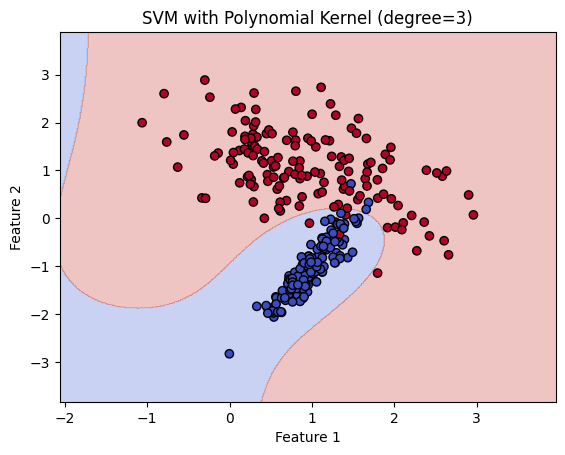

In [4]:
#24.Write a Python program to train an SVM Classifier with a Polynomial Kernel and visualize the decision boundary
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

# Generate synthetic 2D classification dataset for visualization
X, y = make_classification(n_samples=300, n_features=2, n_informative=2,
                           n_redundant=0, n_clusters_per_class=1, random_state=42)

# Split into train/test for completeness
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train SVM with Polynomial Kernel
svm_poly = SVC(kernel='poly', degree=3, C=1.0, coef0=1)
svm_poly.fit(X_train, y_train)

# Plotting decision boundary
def plot_decision_boundary(model, X, y):
    # Set min/max for axes with padding
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                         np.linspace(y_min, y_max, 500))
    # Predict for the whole grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot contour and data points
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("SVM with Polynomial Kernel (degree=3)")
    plt.show()

# Visualize decision boundary
plot_decision_boundary(svm_poly, X, y)


In [5]:
#25.Write a Python program to train a Gaussian Naïve Bayes classifier on the Breast Cancer dataset and evaluate accuracy
# Import necessary libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the Gaussian Naïve Bayes classifier
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Make predictions
y_pred = gnb.predict(X_test)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Print detailed classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Print confusion matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.9737

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.93      0.96        43
           1       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


Confusion Matrix:
 [[40  3]
 [ 0 71]]


In [6]:
#26.Write a Python program to train a Multinomial Naïve Bayes classifier for text classification using the 20 Newsgroups dataset
# Import necessary libraries
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the 20 Newsgroups dataset (using a subset for demonstration)
categories = ['sci.space', 'comp.graphics', 'rec.sport.baseball', 'talk.politics.misc']
data = fetch_20newsgroups(subset='all', categories=categories, remove=('headers', 'footers', 'quotes'))

# Features and labels
X = data.data
y = data.target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert text data into count vectors
vectorizer = CountVectorizer(stop_words='english')
X_train_counts = vectorizer.fit_transform(X_train)
X_test_counts = vectorizer.transform(X_test)

# Train the Multinomial Naïve Bayes classifier
nb = MultinomialNB()
nb.fit(X_train_counts, y_train)

# Make predictions
y_pred = nb.predict(X_test_counts)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=categories))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.8968

Classification Report:
                     precision    recall  f1-score   support

         sci.space       0.92      0.90      0.91       210
     comp.graphics       0.85      0.95      0.90       192
rec.sport.baseball       0.96      0.83      0.89       196
talk.politics.misc       0.86      0.91      0.88       148

          accuracy                           0.90       746
         macro avg       0.90      0.90      0.90       746
      weighted avg       0.90      0.90      0.90       746


Confusion Matrix:
 [[190  10   6   4]
 [  5 182   0   5]
 [ 10  10 163  13]
 [  1  12   1 134]]


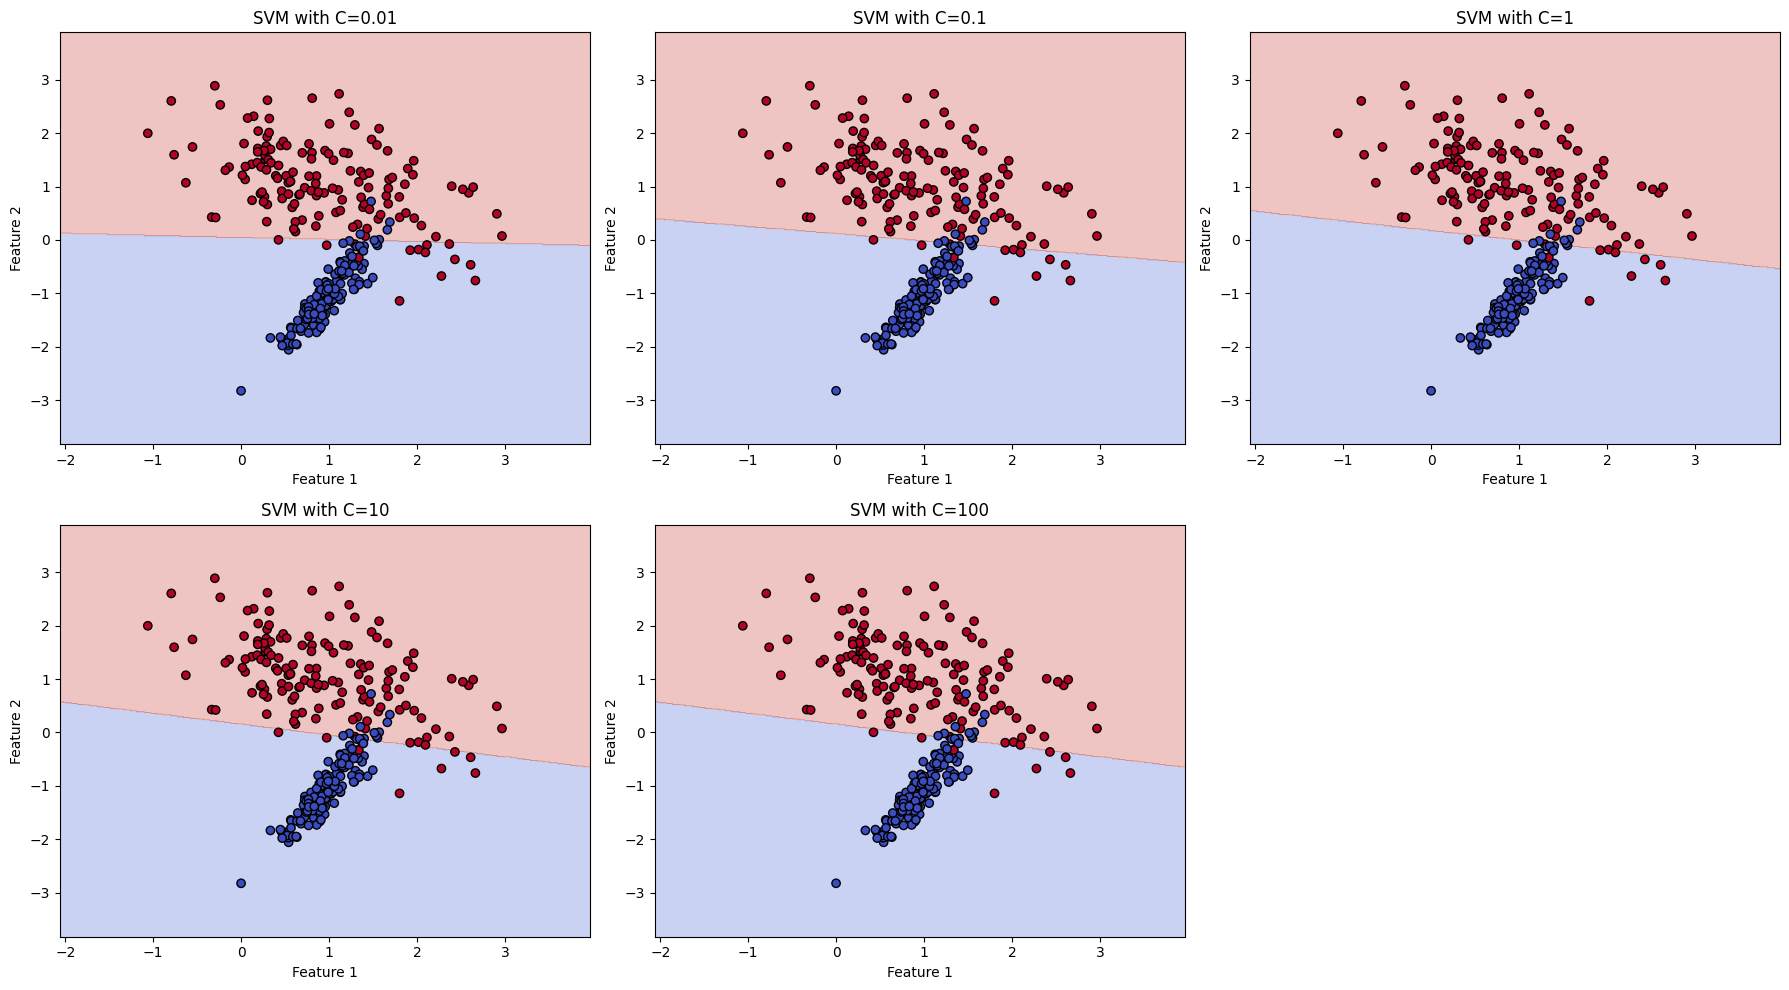

In [7]:
#27.Write a Python program to train an SVM Classifier with different C values and compare the decision boundaries visually
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.svm import SVC

# Generate a synthetic 2D dataset
X, y = make_classification(n_samples=300, n_features=2, n_redundant=0,
                           n_informative=2, n_clusters_per_class=1, random_state=42)

# Function to plot decision boundary
def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                         np.linspace(y_min, y_max, 500))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

# Different C values to test
C_values = [0.01, 0.1, 1, 10, 100]

# Plot decision boundaries for each C
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, C in enumerate(C_values):
    svm = SVC(kernel='linear', C=C)
    svm.fit(X, y)
    plot_decision_boundary(svm, X, y, axes[i], title=f"SVM with C={C}")

# Remove unused subplot (since 2x3=6, but we have 5 plots)
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()


In [8]:
#28.Write a Python program to train a Bernoulli Naïve Bayes classifier for binary classification on a dataset with binary features
# Import necessary libraries
from sklearn.datasets import make_classification
from sklearn.preprocessing import Binarizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Generate a synthetic dataset with continuous features first
X, y = make_classification(n_samples=1000, n_features=10, n_informative=5, n_redundant=0,
                           n_classes=2, random_state=42)

# Binarize the features (convert to 0/1)
binarizer = Binarizer(threshold=0.0)
X_binary = binarizer.fit_transform(X)

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_binary, y, test_size=0.2, random_state=42)

# Train the Bernoulli Naïve Bayes classifier
bnb = BernoulliNB()
bnb.fit(X_train, y_train)

# Make predictions
y_pred = bnb.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.6700

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.67      0.68       104
           1       0.65      0.67      0.66        96

    accuracy                           0.67       200
   macro avg       0.67      0.67      0.67       200
weighted avg       0.67      0.67      0.67       200


Confusion Matrix:
 [[70 34]
 [32 64]]


In [9]:
#29.Write a Python program to apply feature scaling before training an SVM model and compare results with unscaled data
# Import necessary libraries
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Load the Wine dataset
data = load_wine()
X = data.data
y = data.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train SVM without feature scaling
svm_unscaled = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_unscaled.fit(X_train, y_train)
y_pred_unscaled = svm_unscaled.predict(X_test)
accuracy_unscaled = accuracy_score(y_test, y_pred_unscaled)

# Apply feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SVM with scaled features
svm_scaled = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = svm_scaled.predict(X_test_scaled)
accuracy_scaled = accuracy_score(y_test, y_pred_scaled)

# Compare results
print(f"Accuracy without scaling: {accuracy_unscaled:.4f}")
print(f"Accuracy with scaling:    {accuracy_scaled:.4f}")


Accuracy without scaling: 0.8056
Accuracy with scaling:    1.0000


In [10]:
#30Write a Python program to train a Gaussian Naïve Bayes model and compare the predictions before and after Laplace Smoothing
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# Load a subset of the 20 Newsgroups dataset
categories = ['sci.space', 'rec.autos']
data = fetch_20newsgroups(subset='train', categories=categories, remove=('headers', 'footers', 'quotes'))

X = data.data
y = data.target

# Convert text data to count vectors
vectorizer = CountVectorizer()
X_counts = vectorizer.fit_transform(X)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_counts, y, test_size=0.2, random_state=42)

# Train MultinomialNB WITHOUT Laplace Smoothing (alpha=0.0)
nb_no_smoothing = MultinomialNB(alpha=0.0)
nb_no_smoothing.fit(X_train, y_train)
y_pred_no_smoothing = nb_no_smoothing.predict(X_test)
accuracy_no_smoothing = accuracy_score(y_test, y_pred_no_smoothing)

# Train MultinomialNB WITH Laplace Smoothing (alpha=1.0)
nb_with_smoothing = MultinomialNB(alpha=1.0)
nb_with_smoothing.fit(X_train, y_train)
y_pred_with_smoothing = nb_with_smoothing.predict(X_test)
accuracy_with_smoothing = accuracy_score(y_test, y_pred_with_smoothing)

# Compare results
print(f"Accuracy WITHOUT Laplace Smoothing (alpha=0): {accuracy_no_smoothing:.4f}")
print(f"Accuracy WITH Laplace Smoothing (alpha=1):   {accuracy_with_smoothing:.4f}")


Accuracy WITHOUT Laplace Smoothing (alpha=0): 0.5462
Accuracy WITH Laplace Smoothing (alpha=1):   0.9118


/usr/local/lib/python3.11/dist-packages/sklearn/naive_bayes.py:898: RuntimeWarning: divide by zero encountered in log
  self.feature_log_prob_ = np.log(smoothed_fc) - np.log(


In [11]:
#31.Write a Python program to train an SVM Classifier and use GridSearchCV to tune the hyperparameters (C, gamma, kernel)
# Import necessary libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# Load the Iris dataset
data = load_iris()
X = data.data
y = data.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the parameter grid for GridSearchCV
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.1, 1],
    'kernel': ['linear', 'rbf', 'poly']
}

# Create the SVM model
svm = SVC()

# Set up GridSearchCV
grid_search = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit the model with GridSearchCV
grid_search.fit(X_train, y_train)

# Display best parameters
print("Best Parameters:", grid_search.best_params_)

# Predict using the best model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Evaluate the final model
print("\nAccuracy on Test Set:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Best Parameters: {'C': 0.1, 'gamma': 0.1, 'kernel': 'poly'}

Accuracy on Test Set: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [12]:
#32. Write a Python program to train an SVM Classifier on an imbalanced dataset and apply class weighting and check it improve accuracy
# Import necessary libraries
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Generate an imbalanced dataset
X, y = make_classification(n_samples=1000, n_features=2, n_informative=2, n_redundant=0,
                           n_clusters_per_class=1, weights=[0.9, 0.1], flip_y=0, random_state=42)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train SVM without class weighting
svm_no_weight = SVC(kernel='rbf', C=1.0)
svm_no_weight.fit(X_train, y_train)
y_pred_no_weight = svm_no_weight.predict(X_test)

print("Classification Report WITHOUT Class Weights:\n")
print(classification_report(y_test, y_pred_no_weight))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_no_weight))

# Train SVM WITH class weighting (balanced)
svm_with_weight = SVC(kernel='rbf', C=1.0, class_weight='balanced')
svm_with_weight.fit(X_train, y_train)
y_pred_with_weight = svm_with_weight.predict(X_test)

print("\nClassification Report WITH Class Weights:\n")
print(classification_report(y_test, y_pred_with_weight))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_with_weight))


Classification Report WITHOUT Class Weights:

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       176
           1       1.00      0.79      0.88        24

    accuracy                           0.97       200
   macro avg       0.99      0.90      0.93       200
weighted avg       0.98      0.97      0.97       200

Confusion Matrix:
 [[176   0]
 [  5  19]]

Classification Report WITH Class Weights:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       176
           1       1.00      0.92      0.96        24

    accuracy                           0.99       200
   macro avg       0.99      0.96      0.98       200
weighted avg       0.99      0.99      0.99       200

Confusion Matrix:
 [[176   0]
 [  2  22]]


In [13]:
#33.Write a Python program to implement a Naïve Bayes classifier for spam detection using email data
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load dataset (using SMS Spam Collection dataset format as an example)
# Example file: https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip
# Dataset format: label (ham/spam) \t message
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
data = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

# Encode labels: 'ham' → 0, 'spam' → 1
data['label_num'] = data.label.map({'ham': 0, 'spam': 1})

# Features and labels
X = data['message']
y = data['label_num']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert text to feature vectors
vectorizer = CountVectorizer(stop_words='english')
X_train_counts = vectorizer.fit_transform(X_train)
X_test_counts = vectorizer.transform(X_test)

# Train Naïve Bayes classifier (Multinomial is suitable for text counts)
nb = MultinomialNB()
nb.fit(X_train_counts, y_train)

# Predict and evaluate
y_pred = nb.predict(X_test_counts)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.9883

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.97      0.95      0.96       149

    accuracy                           0.99      1115
   macro avg       0.98      0.97      0.97      1115
weighted avg       0.99      0.99      0.99      1115

Confusion Matrix:
 [[961   5]
 [  8 141]]


In [14]:
#34.Write a Python program to train an SVM Classifier and a Naïve Bayes Classifier on the same dataset and compare their accuracy
# Import necessary libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# Load the Iris dataset
data = load_iris()
X = data.data
y = data.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling for SVM (Naïve Bayes doesn't require it, but it doesn't hurt)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SVM Classifier (using RBF kernel)
svm = SVC(kernel='rbf', C=1.0, gamma='scale')
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
accuracy_svm = accuracy_score(y_test, y_pred_svm)

# Train Gaussian Naïve Bayes Classifier
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_nb = gnb.predict(X_test)
accuracy_nb = accuracy_score(y_test, y_pred_nb)

# Print comparison of results
print(f"SVM Accuracy:         {accuracy_svm:.4f}")
print(f"Naïve Bayes Accuracy: {accuracy_nb:.4f}")

print("\nSVM Classification Report:\n", classification_report(y_test, y_pred_svm))
print("Naïve Bayes Classification Report:\n", classification_report(y_test, y_pred_nb))


SVM Accuracy:         1.0000
Naïve Bayes Accuracy: 1.0000

SVM Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Naïve Bayes Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [15]:
#35.Write a Python program to perform feature selection before training a Naïve Bayes classifier and compare results
# Import necessary libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, classification_report

# Load the dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Gaussian Naïve Bayes on ALL features
gnb_full = GaussianNB()
gnb_full.fit(X_train, y_train)
y_pred_full = gnb_full.predict(X_test)
accuracy_full = accuracy_score(y_test, y_pred_full)

# Perform feature selection (e.g., select top 10 features using ANOVA F-test)
selector = SelectKBest(score_func=f_classif, k=10)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Train Gaussian Naïve Bayes on SELECTED features
gnb_selected = GaussianNB()
gnb_selected.fit(X_train_selected, y_train)
y_pred_selected = gnb_selected.predict(X_test_selected)
accuracy_selected = accuracy_score(y_test, y_pred_selected)

# Compare results
print(f"Accuracy with ALL features:      {accuracy_full:.4f}")
print(f"Accuracy with SELECTED features: {accuracy_selected:.4f}")

print("\nClassification Report (Selected Features):\n", classification_report(y_test, y_pred_selected))


Accuracy with ALL features:      0.9737
Accuracy with SELECTED features: 0.9737

Classification Report (Selected Features):
               precision    recall  f1-score   support

           0       1.00      0.93      0.96        43
           1       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [16]:
#36.Write a Python program to train an SVM Classifier using One-vs-Rest (OvR) and One-vs-One (OvO) strategies on the Wine dataset and compare their accuracy
# Import necessary libraries
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load the Wine dataset
data = load_wine()
X = data.data
y = data.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features (important for SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train SVM using One-vs-Rest (OvR)
svm = SVC(kernel='rbf', C=1.0, gamma='scale')
ovr = OneVsRestClassifier(svm)
ovr.fit(X_train, y_train)
y_pred_ovr = ovr.predict(X_test)
accuracy_ovr = accuracy_score(y_test, y_pred_ovr)

# Train SVM using One-vs-One (OvO)
ovo = OneVsOneClassifier(svm)
ovo.fit(X_train, y_train)
y_pred_ovo = ovo.predict(X_test)
accuracy_ovo = accuracy_score(y_test, y_pred_ovo)

# Compare accuracies
print(f"Accuracy with One-vs-Rest (OvR): {accuracy_ovr:.4f}")
print(f"Accuracy with One-vs-One (OvO):  {accuracy_ovo:.4f}")

# Detailed classification reports
print("\nClassification Report (OvR):\n", classification_report(y_test, y_pred_ovr))
print("Classification Report (OvO):\n", classification_report(y_test, y_pred_ovo))



Accuracy with One-vs-Rest (OvR): 1.0000
Accuracy with One-vs-One (OvO):  1.0000

Classification Report (OvR):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

Classification Report (OvO):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [17]:
#37.Write a Python program to train an SVM Classifier using Linear, Polynomial, and RBF kernels on the Breast Cancer dataset and compare their accuracy
# Import necessary libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features (important for SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train SVM with Linear Kernel
svm_linear = SVC(kernel='linear', C=1.0)
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)
accuracy_linear = accuracy_score(y_test, y_pred_linear)

# Train SVM with Polynomial Kernel
svm_poly = SVC(kernel='poly', degree=3, C=1.0, coef0=1)
svm_poly.fit(X_train, y_train)
y_pred_poly = svm_poly.predict(X_test)
accuracy_poly = accuracy_score(y_test, y_pred_poly)

# Train SVM with RBF Kernel
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)

# Compare results
print(f"Accuracy with Linear Kernel:      {accuracy_linear:.4f}")
print(f"Accuracy with Polynomial Kernel:  {accuracy_poly:.4f}")
print(f"Accuracy with RBF Kernel:         {accuracy_rbf:.4f}")

# Detailed classification reports
print("\nClassification Report (Linear):\n", classification_report(y_test, y_pred_linear))
print("Classification Report (Polynomial):\n", classification_report(y_test, y_pred_poly))
print("Classification Report (RBF):\n", classification_report(y_test, y_pred_rbf))



Accuracy with Linear Kernel:      0.9561
Accuracy with Polynomial Kernel:  0.9825
Accuracy with RBF Kernel:         0.9825

Classification Report (Linear):
               precision    recall  f1-score   support

           0       0.93      0.95      0.94        43
           1       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114

Classification Report (Polynomial):
               precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Classification Report (RBF):
               precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1 

In [18]:
#38.Write a Python program to train an SVM Classifier using Stratified K-Fold Cross-Validation and compute the average accuracy
# Import necessary libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import numpy as np

# Load the Iris dataset
data = load_iris()
X = data.data
y = data.target

# Scale features (important for SVM)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Create SVM classifier
svm = SVC(kernel='rbf', C=1.0, gamma='scale')

# Set up Stratified K-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation and compute accuracy for each fold
scores = cross_val_score(svm, X, y, cv=skf, scoring='accuracy')

# Print accuracies and average accuracy
print(f"Accuracy for each fold: {np.round(scores, 4)}")
print(f"Average Accuracy: {scores.mean():.4f}")



Accuracy for each fold: [1.     0.9667 0.9    1.     0.9   ]
Average Accuracy: 0.9533


In [19]:
#39.Write a Python program to train a Naïve Bayes classifier using different prior probabilities and compare performance
# Import necessary libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Calculate the actual class distribution
unique, counts = np.unique(y_train, return_counts=True)
print(f"Actual class distribution in training data: {dict(zip(unique, counts))}")

# Model 1: Using default priors (computed from data)
gnb_default = GaussianNB()
gnb_default.fit(X_train, y_train)
y_pred_default = gnb_default.predict(X_test)
accuracy_default = accuracy_score(y_test, y_pred_default)

# Model 2: Using custom priors (e.g., equal priors for both classes)
priors_equal = [0.5, 0.5]
gnb_equal = GaussianNB(priors=priors_equal)
gnb_equal.fit(X_train, y_train)
y_pred_equal = gnb_equal.predict(X_test)
accuracy_equal = accuracy_score(y_test, y_pred_equal)

# Model 3: Using skewed priors (e.g., favoring class 0 more)
priors_skewed = [0.8, 0.2]
gnb_skewed = GaussianNB(priors=priors_skewed)
gnb_skewed.fit(X_train, y_train)
y_pred_skewed = gnb_skewed.predict(X_test)
accuracy_skewed = accuracy_score(y_test, y_pred_skewed)

# Print results
print(f"\nAccuracy with default priors: {accuracy_default:.4f}")
print(f"Accuracy with equal priors:    {accuracy_equal:.4f}")
print(f"Accuracy with skewed priors:   {accuracy_skewed:.4f}")

print("\nClassification Report (Default Priors):\n", classification_report(y_test, y_pred_default))
print("Classification Report (Equal Priors):\n", classification_report(y_test, y_pred_equal))
print("Classification Report (Skewed Priors):\n", classification_report(y_test, y_pred_skewed))



Actual class distribution in training data: {np.int64(0): np.int64(169), np.int64(1): np.int64(286)}

Accuracy with default priors: 0.9737
Accuracy with equal priors:    0.9737
Accuracy with skewed priors:   0.9649

Classification Report (Default Priors):
               precision    recall  f1-score   support

           0       1.00      0.93      0.96        43
           1       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Classification Report (Equal Priors):
               precision    recall  f1-score   support

           0       1.00      0.93      0.96        43
           1       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Classification Report (Skewed Priors):
           

In [20]:
#40.Write a Python program to perform Recursive Feature Elimination (RFE) before training an SVM Classifier and compare accuracy
# Import necessary libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score, classification_report

# Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features (important for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SVM classifier for RFE
svm_linear = SVC(kernel='linear', C=1.0)

# Apply Recursive Feature Elimination (select top 10 features)
rfe = RFE(estimator=svm_linear, n_features_to_select=10)
rfe.fit(X_train_scaled, y_train)

# Transform datasets using selected features
X_train_rfe = rfe.transform(X_train_scaled)
X_test_rfe = rfe.transform(X_test_scaled)

# Train SVM on ALL features
svm_all = SVC(kernel='linear', C=1.0)
svm_all.fit(X_train_scaled, y_train)
y_pred_all = svm_all.predict(X_test_scaled)
accuracy_all = accuracy_score(y_test, y_pred_all)

# Train SVM on SELECTED features
svm_rfe = SVC(kernel='linear', C=1.0)
svm_rfe.fit(X_train_rfe, y_train)
y_pred_rfe = svm_rfe.predict(X_test_rfe)
accuracy_rfe = accuracy_score(y_test, y_pred_rfe)

# Compare results
print(f"Accuracy with ALL features:      {accuracy_all:.4f}")
print(f"Accuracy with RFE-selected features: {accuracy_rfe:.4f}")

print("\nClassification Report (RFE-selected Features):\n", classification_report(y_test, y_pred_rfe))




Accuracy with ALL features:      0.9561
Accuracy with RFE-selected features: 0.9737

Classification Report (RFE-selected Features):
               precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [21]:
#41.Write a Python program to train an SVM Classifier and evaluate its performance using Precision, Recall, and F1-Score instead of accuracy
# Import necessary libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features (important for SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train SVM Classifier (using RBF kernel)
svm = SVC(kernel='rbf', C=1.0, gamma='scale')
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)

# Evaluate the model
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Detailed classification report and confusion matrix
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Precision: 0.9726
Recall:    1.0000
F1-Score:  0.9861

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Confusion Matrix:
 [[41  2]
 [ 0 71]]


In [22]:
#42.Write a Python program to train a Naïve Bayes Classifier and evaluate its performance using Log Loss (Cross-Entropy Loss)
# Import necessary libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss, classification_report

# Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features (optional for Naïve Bayes, generally improves stability)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Gaussian Naïve Bayes classifier
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Predict probabilities for Log Loss
y_prob = gnb.predict_proba(X_test)

# Calculate Log Loss
loss = log_loss(y_test, y_prob)

# Predict labels for detailed evaluation
y_pred = gnb.predict(X_test)

print(f"Log Loss (Cross-Entropy Loss): {loss:.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))


Log Loss (Cross-Entropy Loss): 0.2051

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



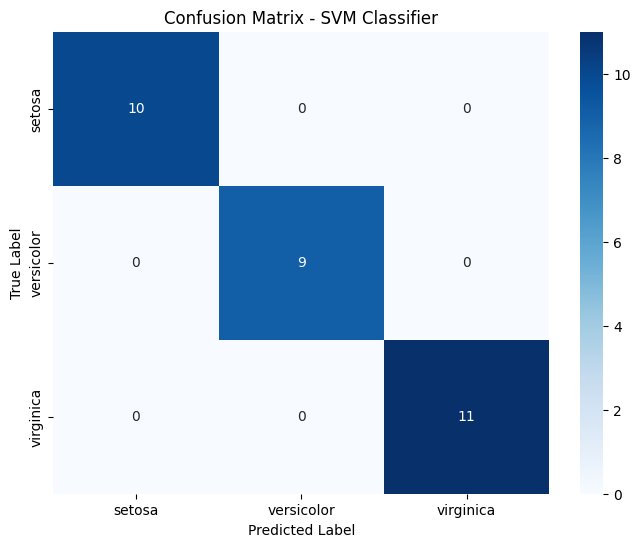


Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [23]:
#43.Write a Python program to train an SVM Classifier and visualize the Confusion Matrix using seaborn
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report

# Load the Iris dataset
data = load_iris()
X = data.data
y = data.target
class_names = data.target_names

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling (important for SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train the SVM Classifier
svm = SVC(kernel='rbf', C=1.0, gamma='scale')
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - SVM Classifier")
plt.show()

# Print classification report for additional metrics
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=class_names))


In [ ]:
#44.Write a Python program to train an SVM Regressor (SVR) and evaluate its performance using Mean Absolute Error (MAE) instead of MSE
# Import necessary libraries
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the California Housing dataset
data = fetch_california_housing()
X = data.data
y = data.target

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling (important for SVR)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()

# Train SVR model (using RBF kernel)
svr = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
svr.fit(X_train_scaled, y_train_scaled)

# Predict and inverse transform predictions to original scale
y_pred_scaled = svr.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

# Evaluate model performance
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")



In [ ]:
#45.Write a Python program to train a Naïve Bayes classifier and evaluate its performance using the ROC-AUC score
# Import necessary libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling (optional for Naïve Bayes but recommended for numerical stability)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Gaussian Naïve Bayes classifier
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Predict probabilities for ROC-AUC calculation
y_prob = gnb.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC score
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
sns.set(style='whitegrid')
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Naïve Bayes Classifier')
plt.legend()
plt.show()



In [ ]:
#46.Write a Python program to train an SVM Classifier and visualize the Precision-Recall Curve.
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import precision_recall_curve, average_precision_score

# Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features (important for SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train SVM Classifier (using probability=True to get probability estimates)
svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
svm.fit(X_train, y_train)

# Predict probabilities for the positive class
y_scores = svm.predict_proba(X_test)[:, 1]

# Calculate precision, recall, and average precision
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
avg_precision = average_precision_score(y_test, y_scores)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
sns.set(style='whitegrid')
plt.plot(recall, precision, color='purple', label=f'AP = {avg_precision:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - SVM Classifier')
plt.legend()
plt.grid(True)
plt.show()

